This project dives into a real-world dataset of 5,975 used cars sold across India, aiming to reveal the hidden factors that influence their market price. Through comprehensive data cleaning, exploratory analysis, and machine learning modeling, we build predictive insights that support smarter negotiations and pricing strategies.

Dataset: https://drive.google.com/file/d/1tvXrd8bUNBm0HlbYrD7VO0nAtJMS26fq/view?usp=sharing

In [34]:
# Step 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [35]:
# step 2:
data = pd.read_csv("used_cars_data.csv")
data.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [36]:
# Step 3
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7207 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          1006 non-null   object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


In [37]:
# check for duplicates
data.nunique()

S.No.                7253
Name                 2041
Location               11
Year                   23
Kilometers_Driven    3660
Fuel_Type               5
Transmission            2
Owner_Type              4
Mileage               450
Engine                150
Power                 386
Seats                   9
New_Price             625
Price                1373
dtype: int64

In [38]:
# checking for nulls and treating them

(data.isnull().sum()/len(data))*100

S.No.                 0.000000
Name                  0.000000
Location              0.000000
Year                  0.000000
Kilometers_Driven     0.000000
Fuel_Type             0.000000
Transmission          0.000000
Owner_Type            0.000000
Mileage               0.027575
Engine                0.634220
Power                 0.634220
Seats                 0.730732
New_Price            86.129877
Price                17.013650
dtype: float64

# Data Reduction

In [39]:
# dropping the unnecessary columns from the model
data.drop(columns=['S.No.', 'New_Price'], inplace = True)

# dropping the rows from the columns that are aprt of the model
data.dropna(subset=['Mileage', 'Engine', 'Power', 'Seats', 'Price'], inplace= True)


In [40]:
# reset index after dropping rows
data.reset_index(drop=True, inplace = True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   object 
 8   Engine             5975 non-null   object 
 9   Power              5975 non-null   object 
 10  Seats              5975 non-null   float64
 11  Price              5975 non-null   float64
dtypes: float64(2), int64(2), object(8)
memory usage: 560.3+ KB


# Feature Engineering

In [41]:
data['Brand'] = data.Name.str.split().str.get(0)
data['Model'] = data.Name.str.split().str.get(1) + data.Name.str.split().str.get(2)

In [42]:
data[['Name', 'Brand', 'Model']]

,Name,Brand,Model
0,Maruti Wagon R LXI CNG,Maruti,WagonR
1,Hyundai Creta 1.6 CRDi SX Option,Hyundai,Creta1.6
2,Honda Jazz V,Honda,JazzV
3,Maruti Ertiga VDI,Maruti,ErtigaVDI
4,Audi A4 New 2.0 TDI Multitronic,Audi,A4New
...,...,...,...
5970,Maruti Swift VDI,Maruti,SwiftVDI
5971,Hyundai Xcent 1.1 CRDi S,Hyundai,Xcent1.1
5972,Mahindra Xylo D4 BSIV,Mahindra,XyloD4
5973,Maruti Wagon R VXI,Maruti,WagonR


In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   object 
 8   Engine             5975 non-null   object 
 9   Power              5975 non-null   object 
 10  Seats              5975 non-null   float64
 11  Price              5975 non-null   float64
 12  Brand              5975 non-null   object 
 13  Model              5975 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 653.6+ KB


In [44]:
from datetime import date

date.today().year
data['Car_Age'] = date.today().year - data['Year']
data.head()

,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price,Brand,Model,Car_Age
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75,Maruti,WagonR,15
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50,Hyundai,Creta1.6,10
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50,Honda,JazzV,14
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00,Maruti,ErtigaVDI,13
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74,Audi,A4New,12


In [45]:
pd.to_numeric

<function pandas.core.tools.numeric.to_numeric(arg, errors: 'DateTimeErrorChoices' = 'raise', downcast: "Literal['integer', 'signed', 'unsigned', 'float'] | None" = None, dtype_backend: 'DtypeBackend | lib.NoDefault' = <no_default>)>

In [46]:
# Power

data['Power'] = data.Power.str.split().str.get(0)
data['Power'] = pd.to_numeric(data['Power'], errors= 'coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   object 
 8   Engine             5975 non-null   object 
 9   Power              5872 non-null   float64
 10  Seats              5975 non-null   float64
 11  Price              5975 non-null   float64
 12  Brand              5975 non-null   object 
 13  Model              5975 non-null   object 
 14  Car_Age            5975 non-null   int64  
dtypes: float64(3), int64(3), object(9)
memory usage: 700.3+ KB


In [47]:
data['Engine'] = data.Engine.str.split().str.get(0)
data['Engine'] = pd.to_numeric(data['Engine'], errors= 'coerce')

In [48]:
data['Seats'] = data['Seats'].astype(str)

In [49]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   object 
 8   Engine             5975 non-null   int64  
 9   Power              5872 non-null   float64
 10  Seats              5975 non-null   object 
 11  Price              5975 non-null   float64
 12  Brand              5975 non-null   object 
 13  Model              5975 non-null   object 
 14  Car_Age            5975 non-null   int64  
dtypes: float64(2), int64(4), object(9)
memory usage: 700.3+ KB


In [50]:
import numpy as np

In [51]:
# function to convert km/kg to kmpl

def convert_to_kmpl(mileage):
    if 'km/kg' in mileage:
        value = float(mileage.replace(" km/kg", "")) # extract numerical value
        return value * 1.4 # replace with kmpl value
    elif 'kmpl' in mileage:
        value = float(mileage.replace(" kmpl", ""))
        return value # keep kmpl value as is
    else:
        return np.nan  # handle any unexpected values

In [52]:
print(convert_to_kmpl("24.5 km/kg"))
print(convert_to_kmpl("24.5 kmpl"))
print(convert_to_kmpl("24.5 "))

34.3
24.5
nan


In [53]:
# apply convert to kmpl function on mileage column

data['Mileage'] = data['Mileage'].apply(lambda x : convert_to_kmpl(str(x)))
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5975 entries, 0 to 5974
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               5975 non-null   object 
 1   Location           5975 non-null   object 
 2   Year               5975 non-null   int64  
 3   Kilometers_Driven  5975 non-null   int64  
 4   Fuel_Type          5975 non-null   object 
 5   Transmission       5975 non-null   object 
 6   Owner_Type         5975 non-null   object 
 7   Mileage            5975 non-null   float64
 8   Engine             5975 non-null   int64  
 9   Power              5872 non-null   float64
 10  Seats              5975 non-null   object 
 11  Price              5975 non-null   float64
 12  Brand              5975 non-null   object 
 13  Model              5975 non-null   object 
 14  Car_Age            5975 non-null   int64  
dtypes: float64(3), int64(4), object(8)
memory usage: 700.3+ KB


# Data Wrangling/Data Cleaning

In [54]:
print(data.Brand.unique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra' 'Ford'
 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda' 'Mini' 'Fiat'
 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'ISUZU' 'Force' 'Bentley'
 'Lamborghini']


In [55]:
data['Brand'].replace({'ISUZU':'Isuzu', 'Land':'Land Rover', 'Mini': 'Mini Cooper'}, inplace = True)
print(data.Brand.unique())

['Maruti' 'Hyundai' 'Honda' 'Audi' 'Nissan' 'Toyota' 'Volkswagen' 'Tata'
 'Land Rover' 'Mitsubishi' 'Renault' 'Mercedes-Benz' 'BMW' 'Mahindra'
 'Ford' 'Porsche' 'Datsun' 'Jaguar' 'Volvo' 'Chevrolet' 'Skoda'
 'Mini Cooper' 'Fiat' 'Jeep' 'Smart' 'Ambassador' 'Isuzu' 'Force'
 'Bentley' 'Lamborghini']


In [56]:
# checking the data for all features
print(data.Location.unique())
print(data.Fuel_Type.unique())
print(data.Transmission.unique())
print(data.Owner_Type.unique())
print(data.Seats.unique())
print(data.Model.unique())

['Mumbai' 'Pune' 'Chennai' 'Coimbatore' 'Hyderabad' 'Jaipur' 'Kochi'
 'Kolkata' 'Delhi' 'Bangalore' 'Ahmedabad']
['CNG' 'Diesel' 'Petrol' 'LPG']
['Manual' 'Automatic']
['First' 'Second' 'Fourth & Above' 'Third']
['5.0' '7.0' '8.0' '4.0' '6.0' '2.0' '10.0' '9.0' '0.0']
['WagonR' 'Creta1.6' 'JazzV' 'ErtigaVDI' 'A4New' 'EONLPG' 'MicraDiesel'
 'InnovaCrysta' 'VentoDiesel' 'IndicaVista' 'CiazZeta' 'City1.5'
 'SwiftVDI' 'RoverRange' 'RoverFreelander' 'PajeroSport' 'AmazeS'
 'SwiftDDiS' 'Duster85PS' 'NewC-Class' '3Series' 'SCross' 'A62011-2015'
 'i201.2' 'VentoPetrol' 'CityCorporate' 'AltoK10' 'WRVi-VTEC' 'Innova2.5'
 'Duster110PS' 'CorollaAltis' 'SsangyongRexton' 'A62.7' 'Vento1.6'
 'VitaraBrezza' 'KUV100' 'M-ClassML' 'PoloDiesel' 'AltoLXi' 'NanoLX'
 'i20Magna' 'Elantra2.0' 'ElantraCRDi' 'Xcent1.1' 'TharCRDe' 'A42.0'
 'SwiftLDI' 'SwiftLdi' 'Grandi10' 'Vento2013-2015' 'KWIDRXT' 'i10Asta'
 'X-TrailSLX' 'ZenEstilo' 'FigoDiesel' 'IndicaV2' 'CityZX'
 'C-ClassProgressive' 'ErtigaSHVS' 'Creta1.4' '

# EDA

In [57]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,5975.0,2013.386778,3.247238,1998.00,2012.00,2014.00,2016.00,2019.000
Kilometers_Driven,5975.0,58674.314979,91558.514361,171.00,33908.00,53000.00,73000.00,6500000.000
Mileage,5975.0,18.287676,4.823919,0.00,15.26,18.20,21.10,46.956
Engine,5975.0,1621.606695,601.036987,624.00,1198.00,1493.00,1984.00,5998.000
Power,5872.0,113.276894,53.881892,34.20,75.00,97.70,138.10,560.000
Price,5975.0,9.501647,11.205736,0.44,3.50,5.65,9.95,160.000
Car_Age,5975.0,11.613222,3.247238,6.00,9.00,11.00,13.00,27.000


**Analysis:**
- Year ranges from 1998 to 2019. This implies a high range of 21 years with mopst of the cars falling between 2012 to 2019 (75%).This implies that data contains both old and latest model.
- Average kilimeters drives is ~59 KM. The range is huge (around 64 lakh) implying presence of outliers in the columns. It means we need to remove the outliers from this column.
- The minimum value in Mileage column is 0, which can not be sold. This appears like a data entry issue.
- Both Engine and Power have outliers and data seem to be rightly skewed.
- The max price for the used car is 160K, which is quite high for the used car. This may be aan outlier or a data entry issue.
- Avg age of car is ~12 years. 

The descriptive statistics indicates high skewness in the dataset which is mainly because of the presence of busget and luxury cars in the same data set. 
- 25th percentile (Q1): ₹3.5 lakhs

- Median (Q2): ₹5.65 lakhs

- 75th percentile (Q3): ₹9.95 lakhs

- Max: ₹160 lakhs

Therefore, I have decided to define a price threshold to segment budget vs luxury cars using folowing rule:

- Budget cars: Price < 10 lakhs (below 75th percentile)

- Luxury cars: Price >= 10 lakhs

This simple but effective approach can help us to have better data analysis and develop a robust price predictor model. 

In [68]:
budget_cars = data[data['Price'] < 10]
luxury_cars = data[data['Price'] >= 10]

In [69]:
cat_col = budget_cars.select_dtypes(include=["object"]).columns.tolist()
num_col = budget_cars.select_dtypes(include=np.number).columns.tolist()
print("Categorical columns are")
print(cat_col)
print("Numerical columns are:")
print(num_col)

Categorical columns are
['Name', 'Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Seats', 'Brand', 'Model']
Numerical columns are:
['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Price', 'Car_Age']


# EDA Univariate Analysis (Data Viz)

Year
Skewness: -0.42


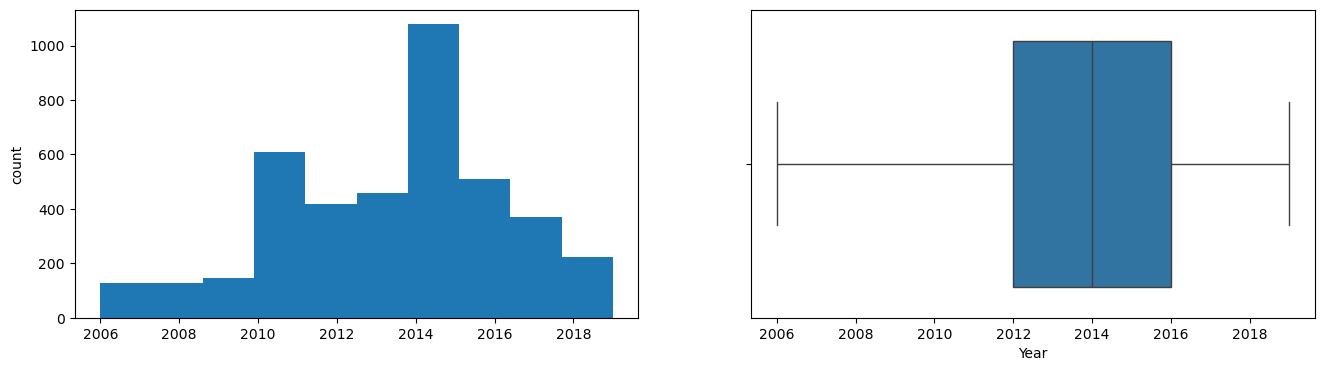

Kilometers_Driven
Skewness: 0.39


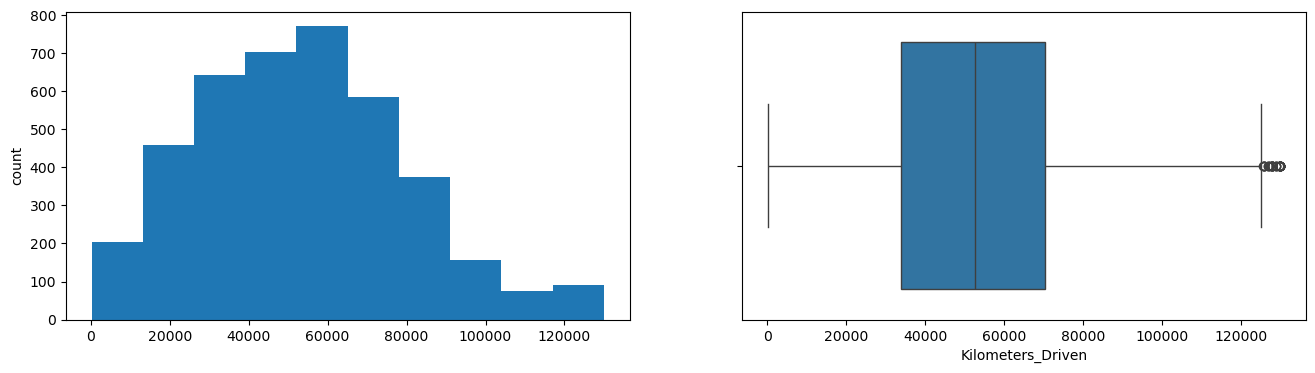

Mileage
Skewness: 0.06


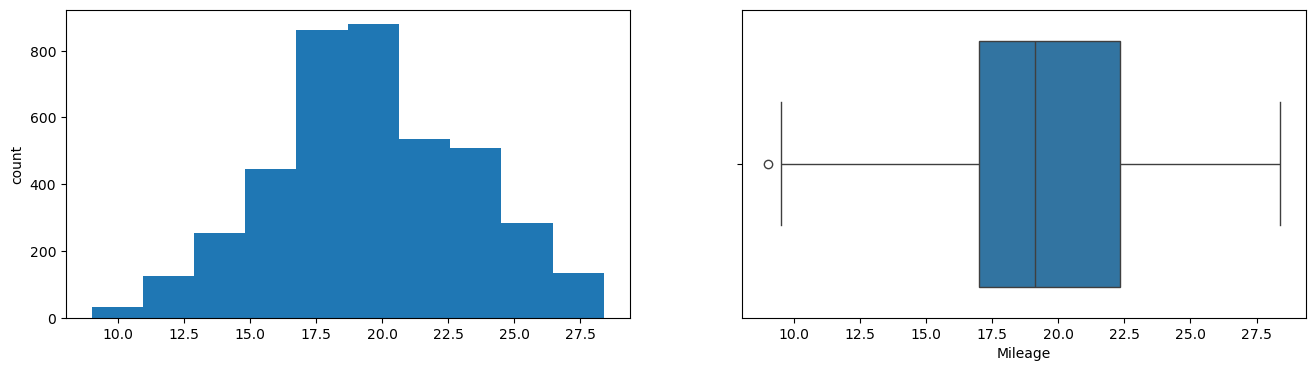

Engine
Skewness: 1.32


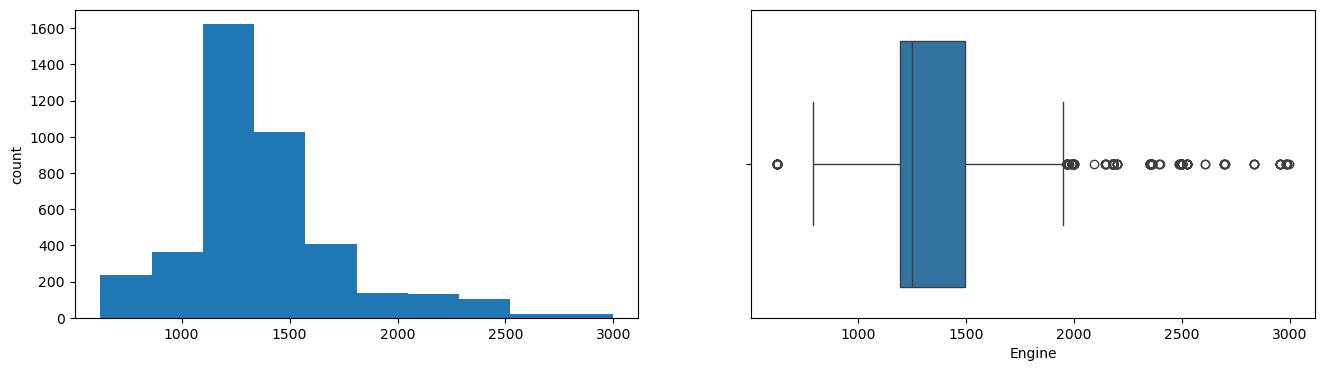

Power
Skewness: 1.1


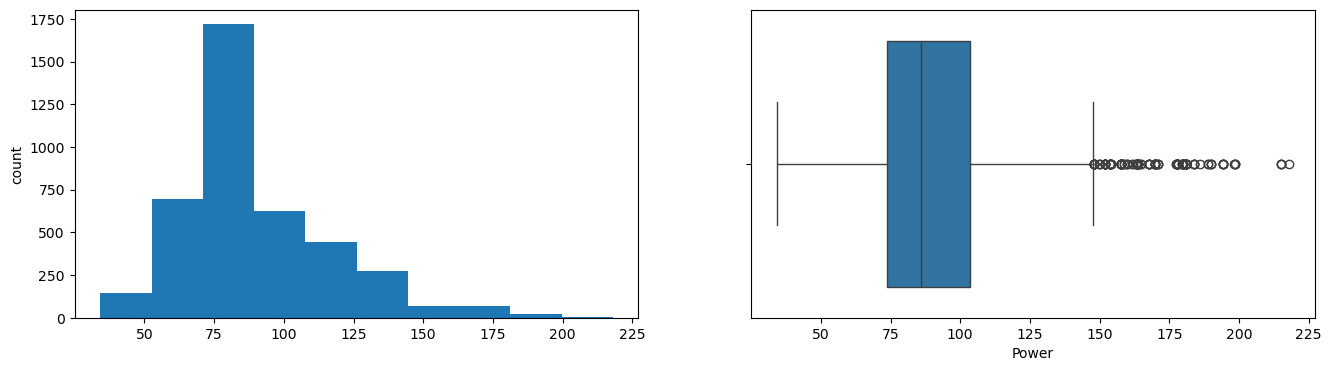

Price
Skewness: 0.37


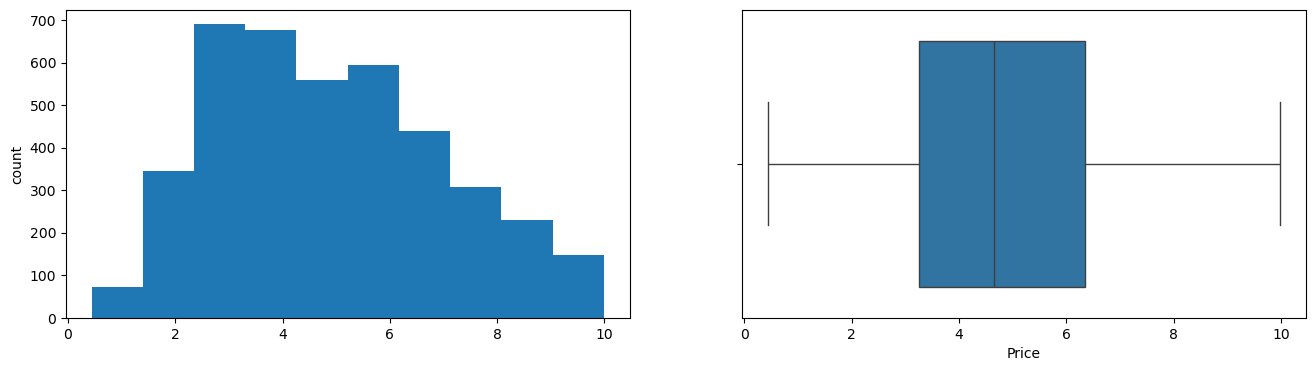

Car_Age
Skewness: 0.42


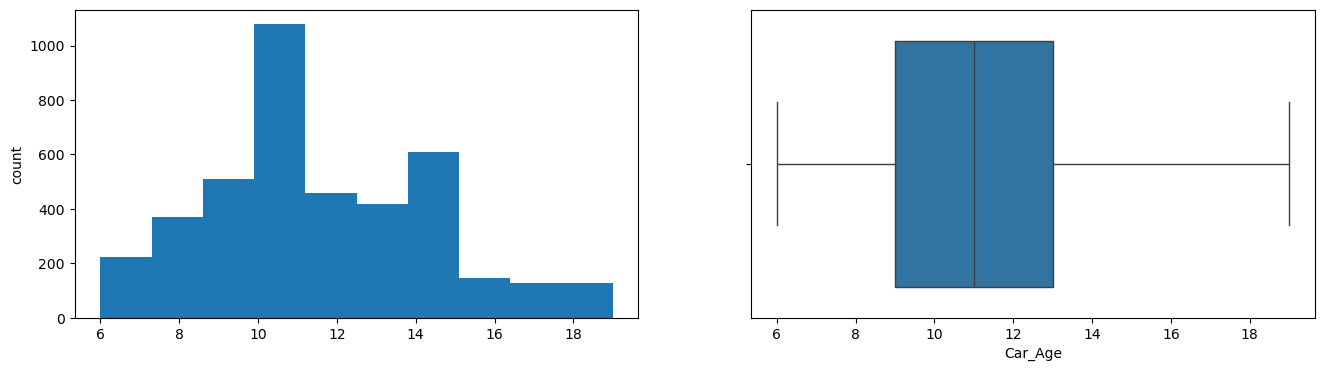

In [70]:
for col in num_col:
    print(col)
    print("Skewness:", round(budget_cars[col].skew(),2))
    plt.figure(figsize=(16,4))
    plt.subplot(1,2,1)
    budget_cars[col].hist(grid=False)
    plt.ylabel("count")
    plt.subplot(1,2,2)
    sns.boxplot(x=budget_cars[col])
    plt.show()

In [71]:
# Outlier Removal
for col in num_col:
    Q1 = budget_cars[col].quantile(0.25)
    Q3 = budget_cars[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    budget_cars = budget_cars[(budget_cars[col]>=lower_bound) & (budget_cars[col]<=upper_bound)]

Year
Skewness: -0.53


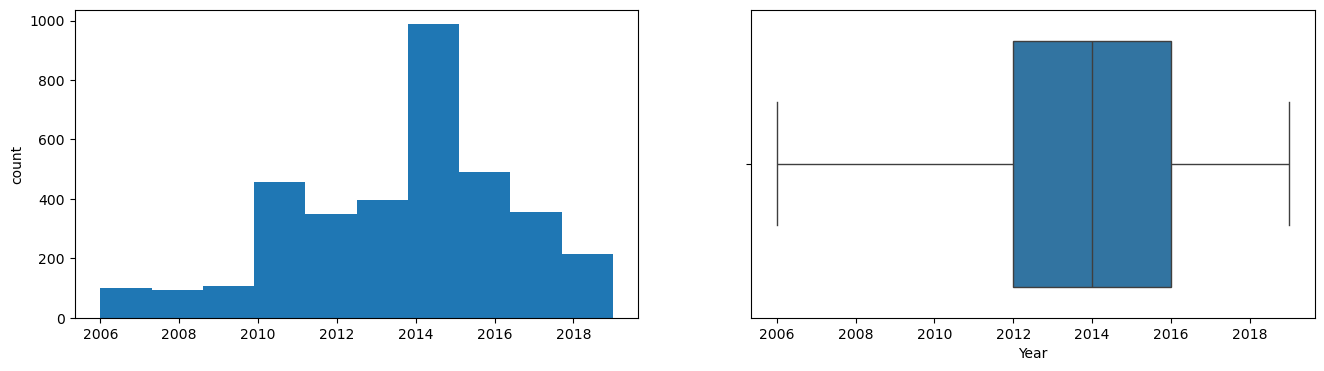

Kilometers_Driven
Skewness: 0.35


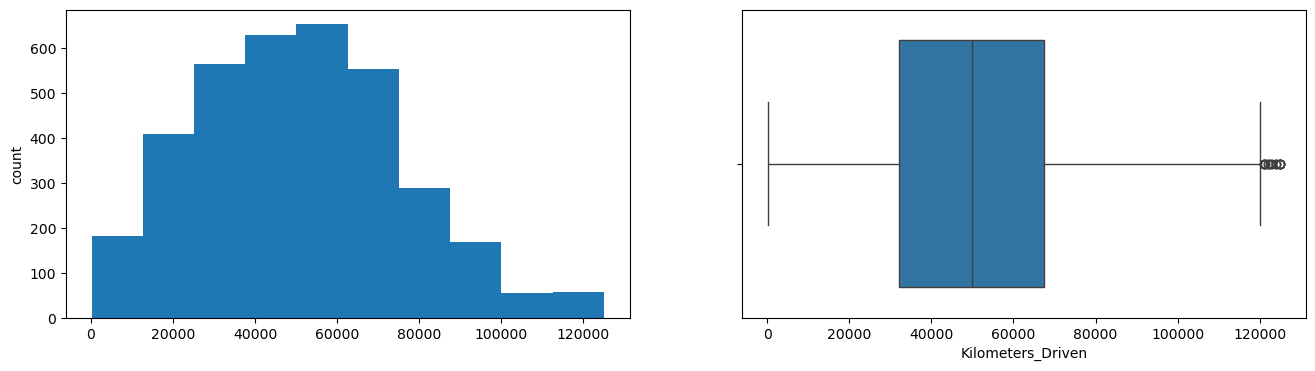

Mileage
Skewness: 0.31


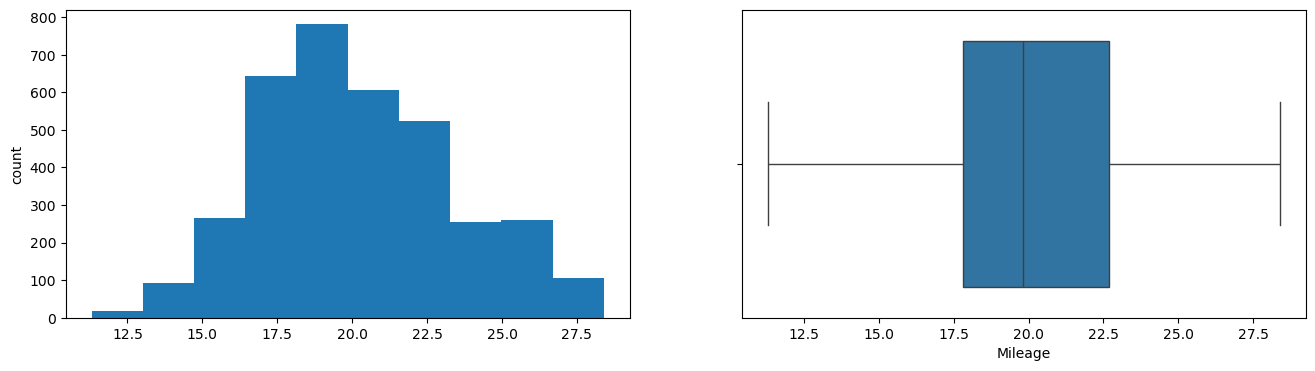

Engine
Skewness: -0.09


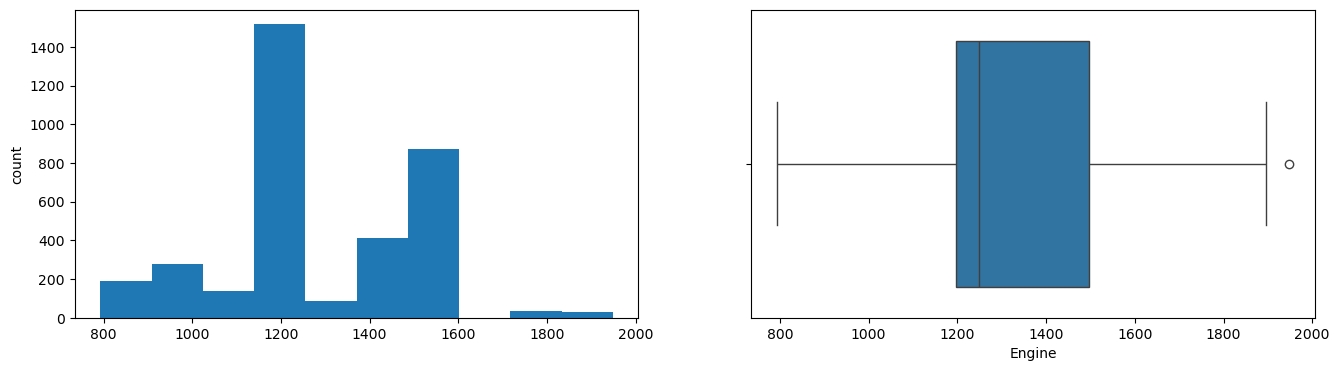

Power
Skewness: 0.41


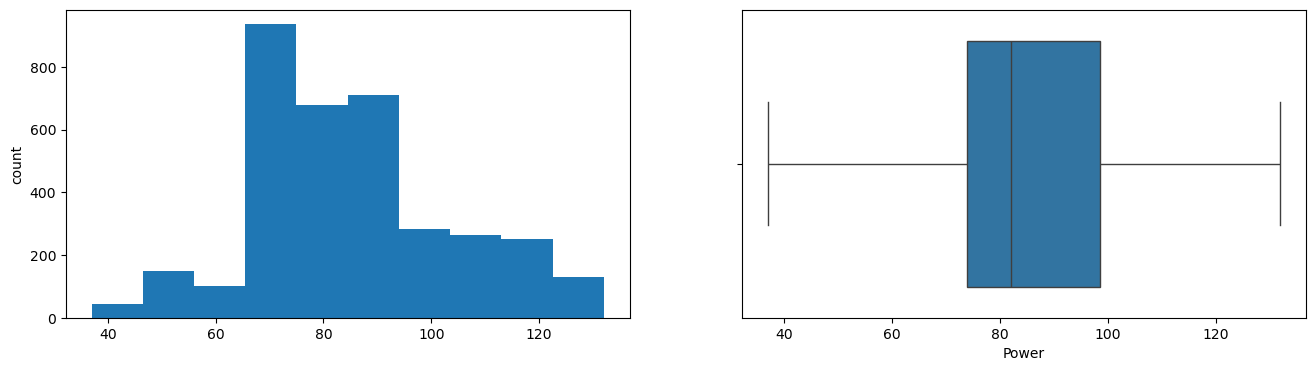

Price
Skewness: 0.42


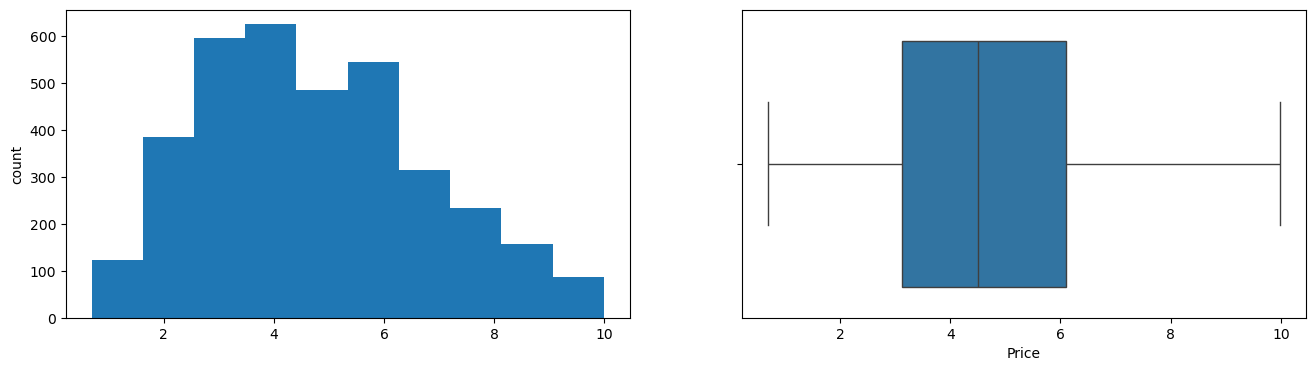

Car_Age
Skewness: 0.53


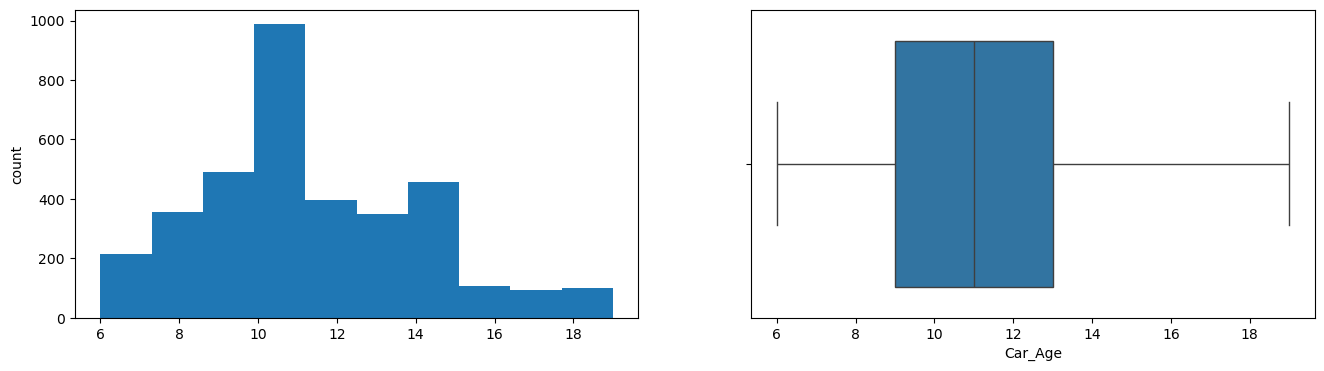

In [72]:
# EDA post outlier removals
for col in num_col:
    print(col)
    print("Skewness:", round(budget_cars[col].skew(),2))
    plt.figure(figsize=(16,4))
    plt.subplot(1,2,1)
    budget_cars[col].hist(grid=False)
    plt.ylabel("count")
    plt.subplot(1,2,2)
    sns.boxplot(x=budget_cars[col])
    plt.show()

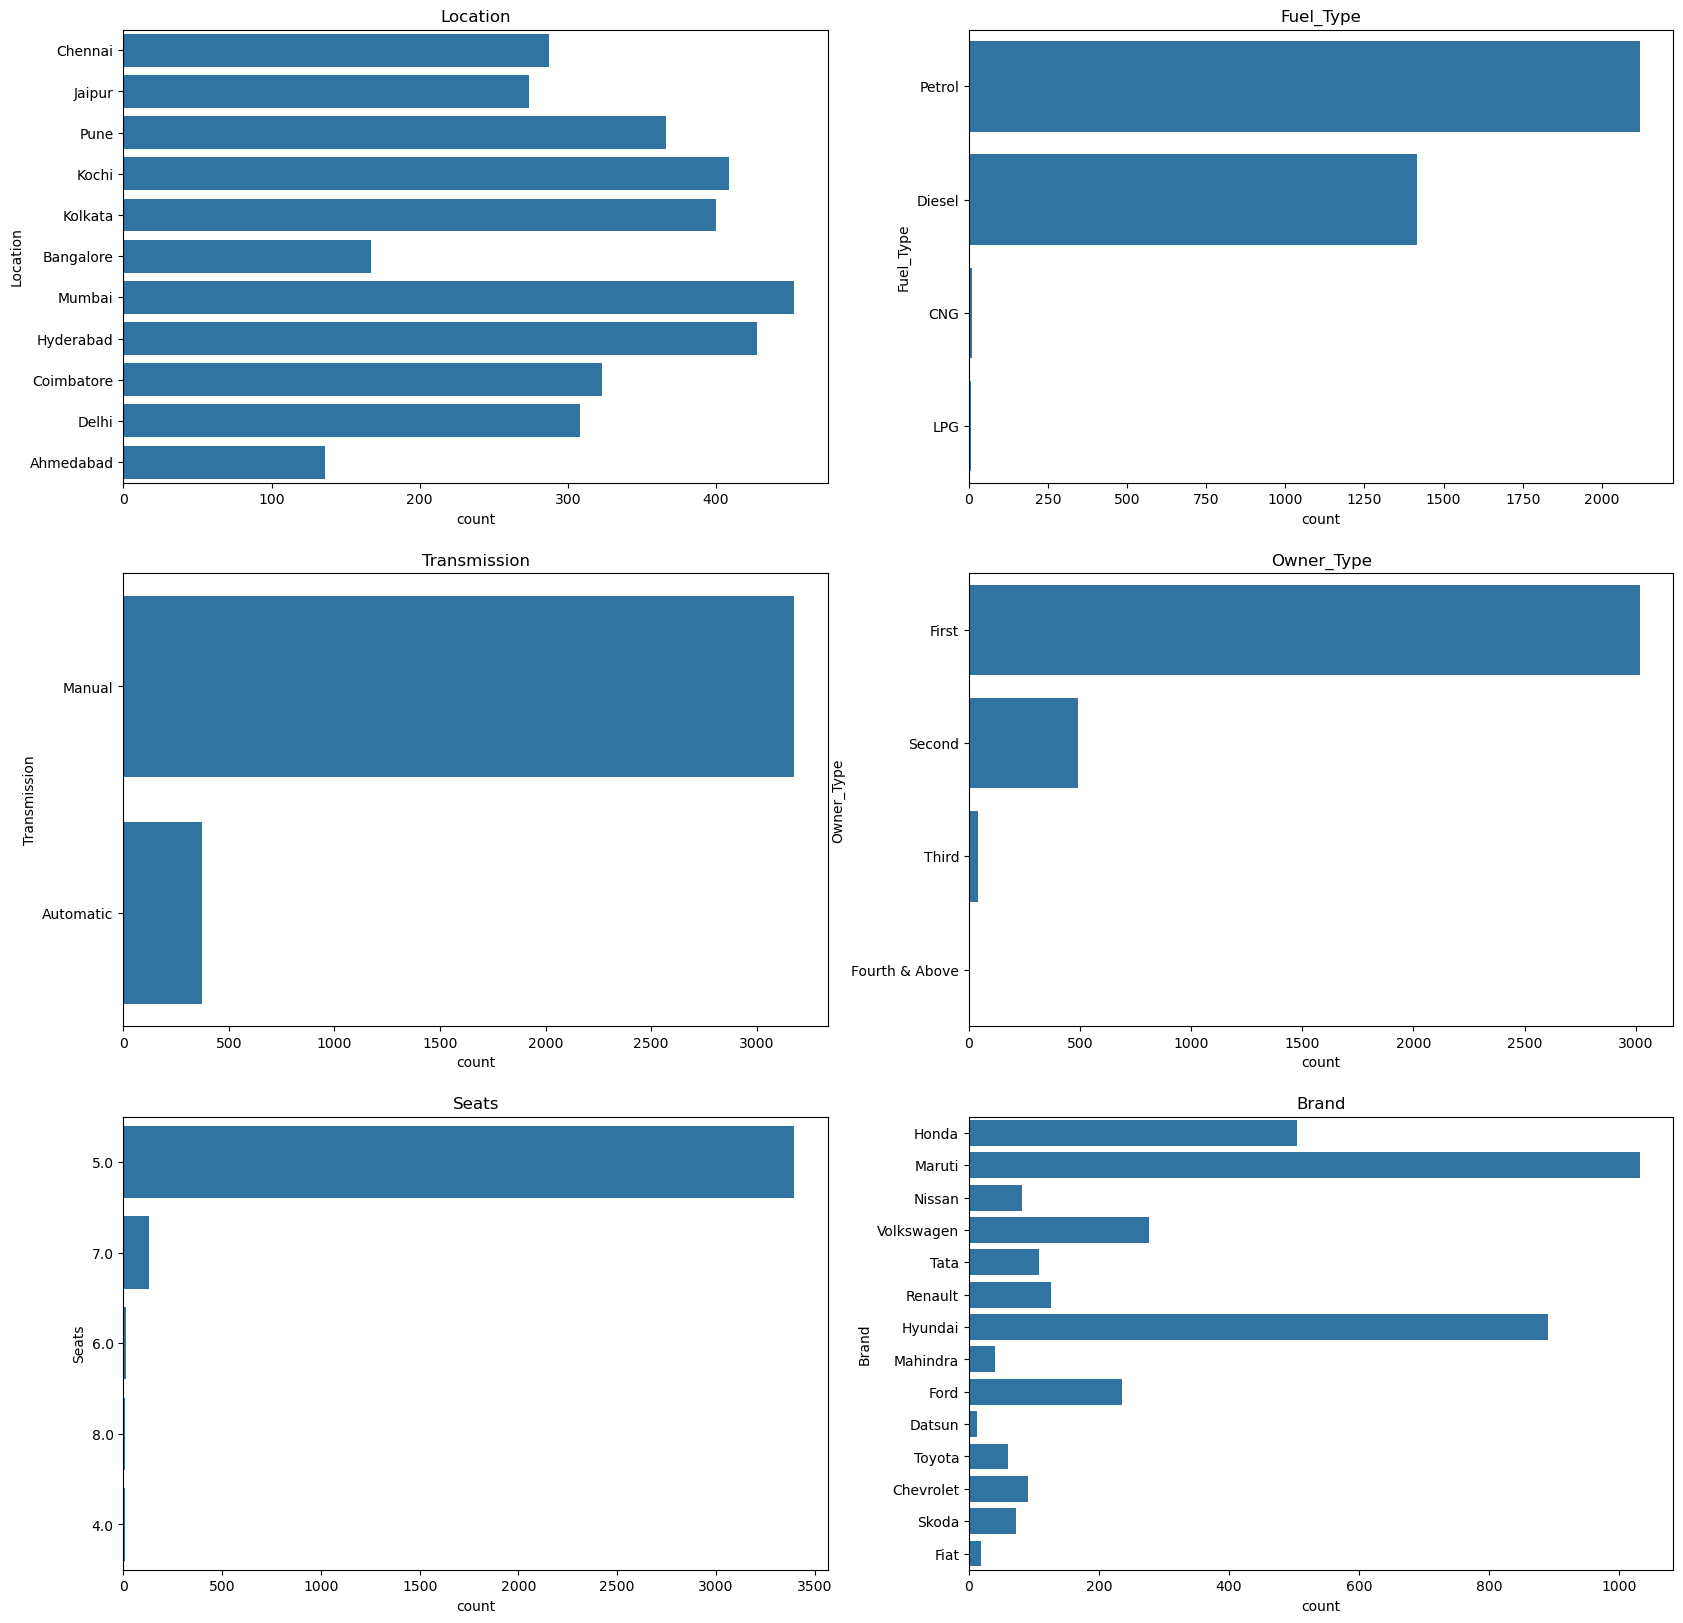

In [79]:
plt.figure(figsize=(20,20))
for i in range(1,7):
    plt.subplot(3,2,i)
    plt.title(cat_col[i])
    sns.countplot(data=budget_cars[cat_col[i]])
plt.show()

From the countplot of categorical columns, we can dervie following observations:
- Mumbai has the highest number of budget cars available for purchases, followed by Hyderabad and then Kochi.
- Most of the cars available for purchases are Diesel as diesel cars provide better performance.
- Majority budget cars have Manual transmission
- Majority cars are first owned followed by second hand owned cars.
- Majority cars available for purchase are 5-seater followed by 7-seater.
- Maruti ranks first among all the budget car brands available in used car market.

# Bivariate EDA

<Figure size 1600x2000 with 0 Axes>

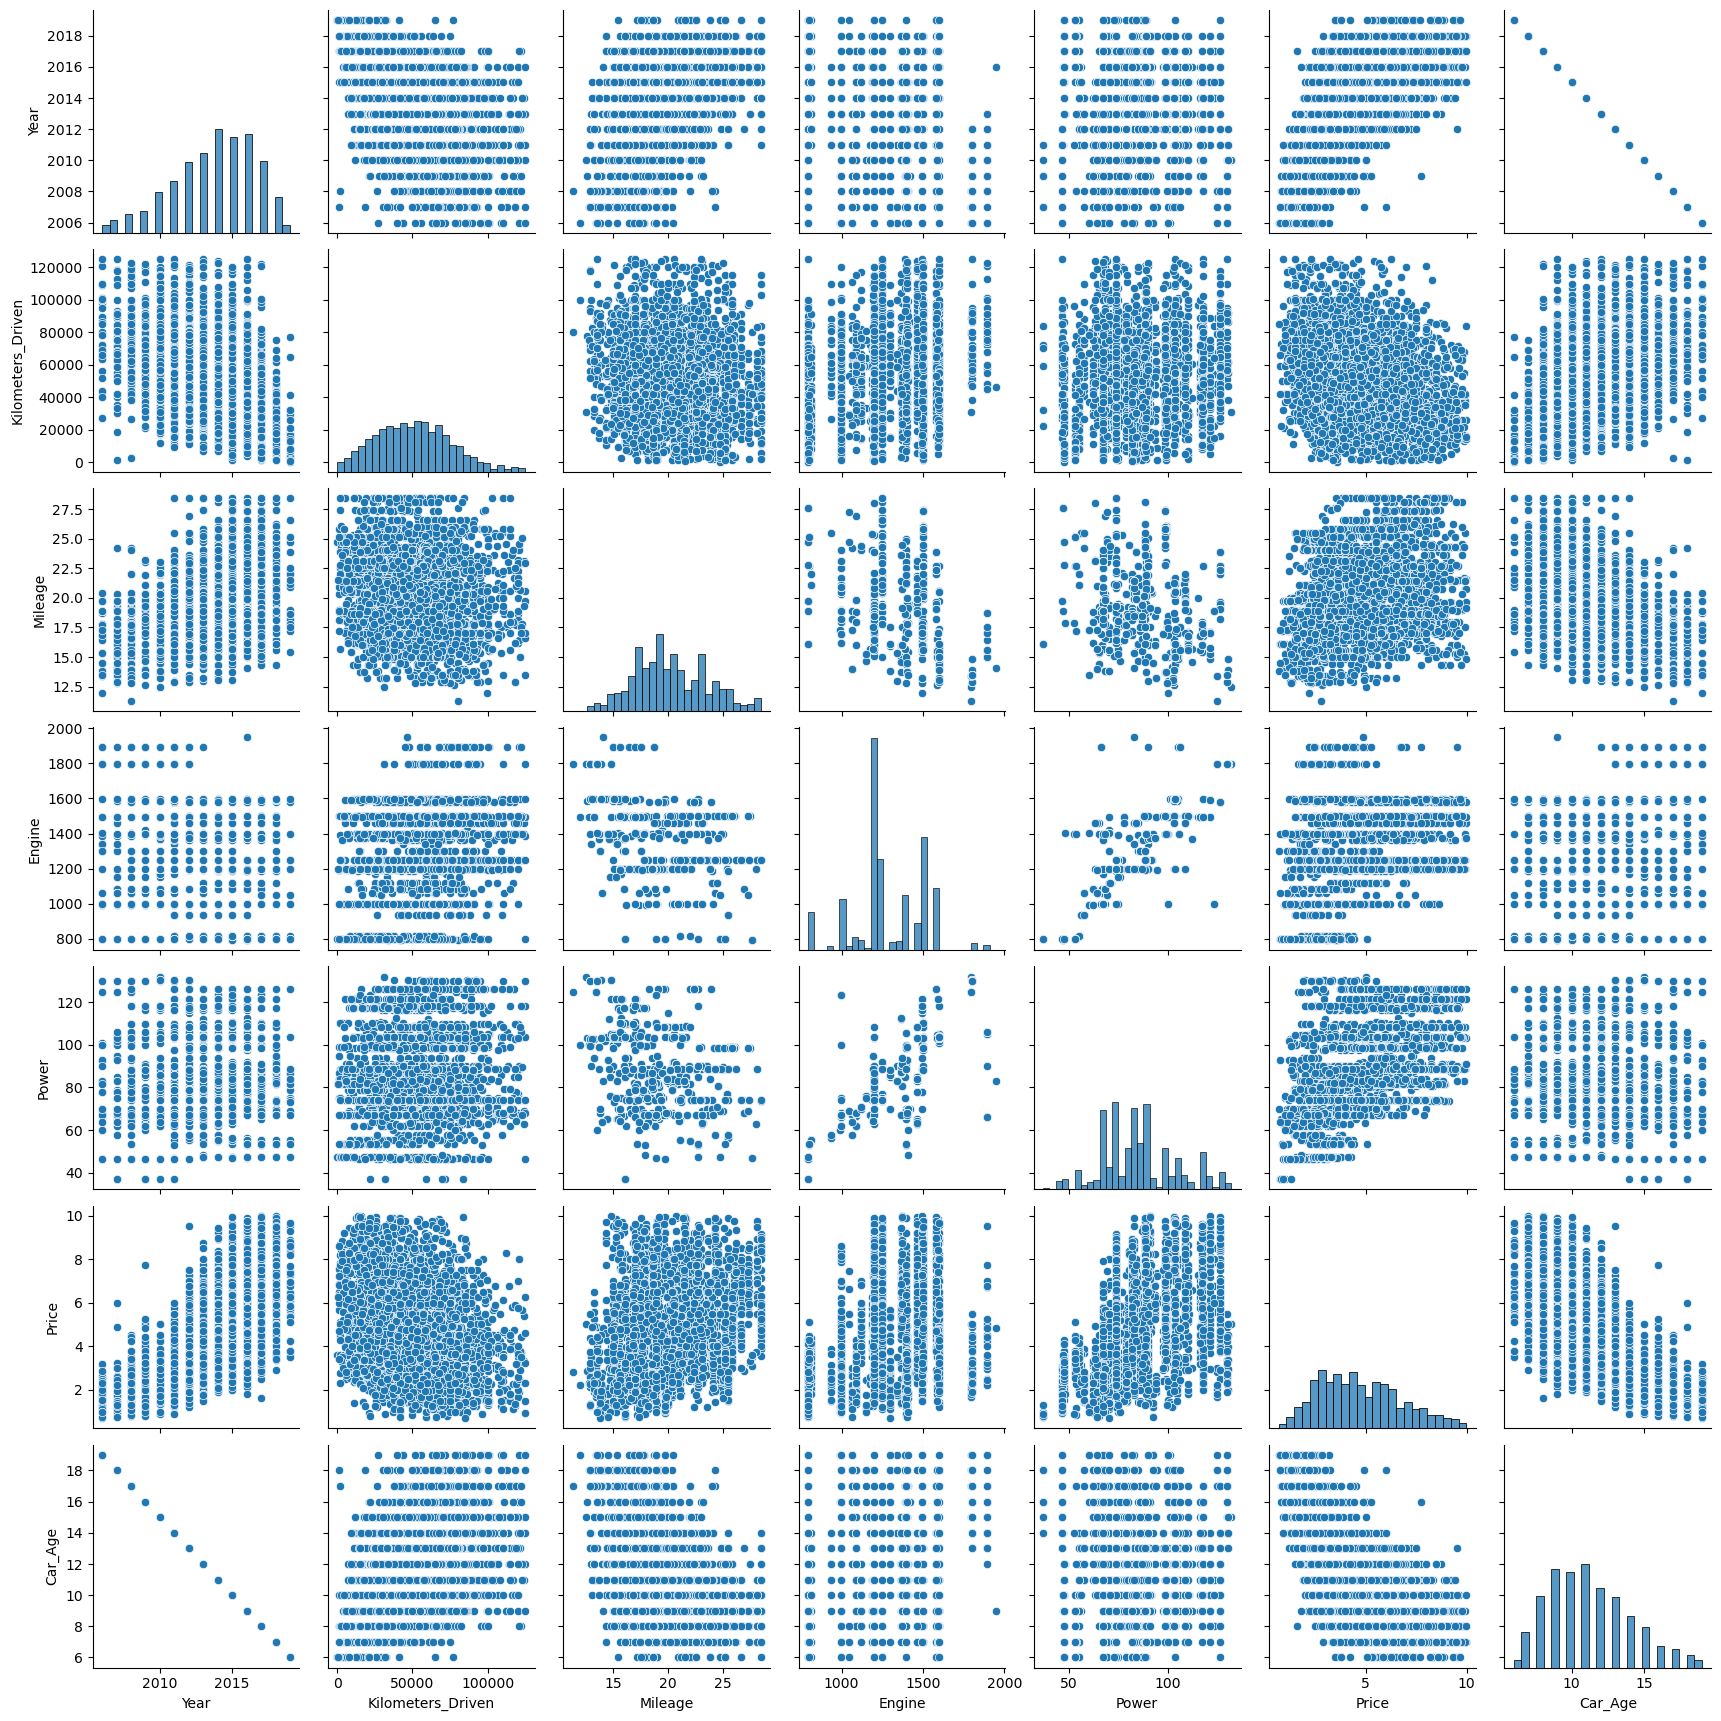

In [80]:
# pairplot
plt.figure(figsize=(16,20))
sns.pairplot(budget_cars)
plt.show()

# Multivariate Analysis

In [83]:
data_num = budget_cars.select_dtypes(include=['number'])
corr_matrix = data_num.corr()
corr_matrix

,Year,Kilometers_Driven,Mileage,Engine,Power,Price,Car_Age
Year,1.000000,-0.501776,0.379922,-0.136050,-0.001010,0.679821,-1.000000
Kilometers_Driven,-0.501776,1.000000,-0.021840,0.241794,0.072681,-0.286675,0.501776
Mileage,0.379922,-0.021840,1.000000,-0.236919,-0.283381,0.210052,-0.379922
Engine,-0.136050,0.241794,-0.236919,1.000000,0.814885,0.320873,0.136050
Power,-0.001010,0.072681,-0.283381,0.814885,1.000000,0.449627,0.001010
Price,0.679821,-0.286675,0.210052,0.320873,0.449627,1.000000,-0.679821
Car_Age,-1.000000,0.501776,-0.379922,0.136050,0.001010,-0.679821,1.000000


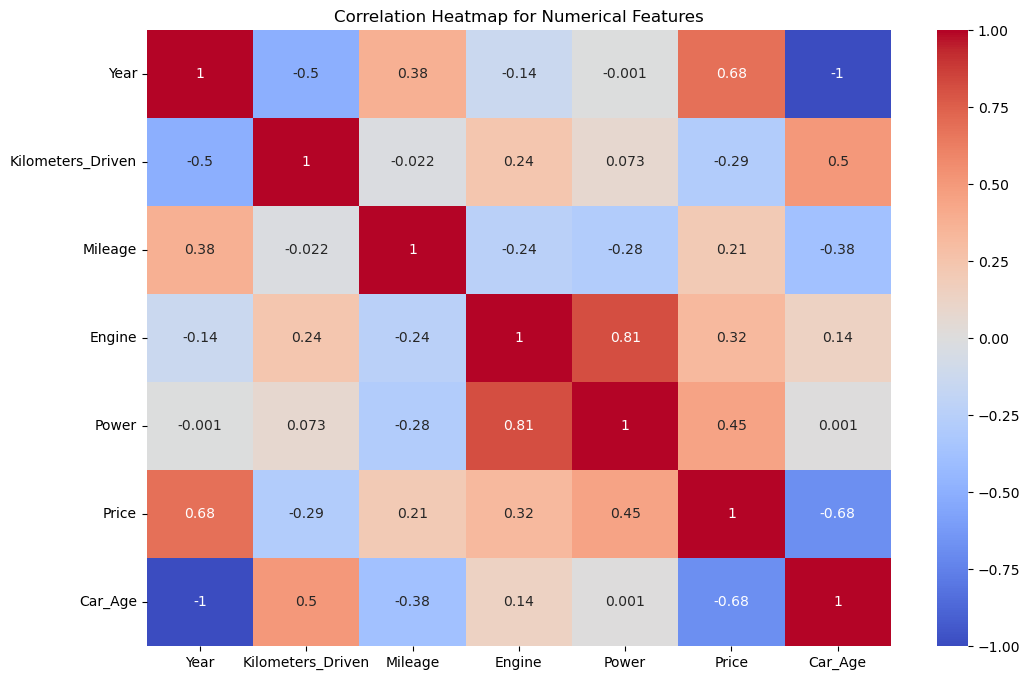

In [84]:
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2g',cmap='coolwarm')
plt.title("Correlation Heatmap for Numerical Features")
plt.show()

The correlation matrix indicates prefect negative correlation between year and car, which is as expected, since car_age is derived from the year. So, we can keep either of the two in our price predictor model. I have selected car_age as this will help us to identify for each passing year what is the average drop in price of the used car. 

# Price Predictor Model of Budget Cars

Since Price is our target variable, we need to identify the features that which should include in our model. 

In [86]:
# Get the correlation matrix
corr_matrix = budget_cars.corr(numeric_only=True)

# Extract correlation of all features with 'Price'
price_corr = corr_matrix['Price'].sort_values(ascending=False)

# Display it
print(price_corr)

Price                1.000000
Year                 0.679821
Power                0.449627
Engine               0.320873
Mileage              0.210052
Kilometers_Driven   -0.286675
Car_Age             -0.679821
Name: Price, dtype: float64


From the table, the high correlation features are Year(dropping it as we are taking car_age instead), Power, Engine, Mileage. We are dropping kilometers driven as weak negative correlation could add noise. However, power and engine also have high correlation, keeping both can introduce the problem of multicollinearity. 

In [92]:
# Checking for the presence of multicollinearity.
!pip install statsmodels
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

features = ['Car_Age', 'Power', 'Engine', 'Mileage']

# Creating Subset of the dataset
X = budget_cars[features]

# Adding constant for intercept
X_const = add_constant(X)

# Calculating VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]

print(vif_data)

   Feature       VIF
0  Car_Age  1.264495
1    Power  3.296888
2   Engine  3.174344
3  Mileage  1.300221


Even though Power and Engine have a high pairwise correlation (~0.81), their VIFs are still below the threshold of 5, which means we can keep both in the model without serious multicollinearity issues.

In [99]:
# creating features and target variable
X = pd.DataFrame(data=budget_cars, columns=["Car_Age", "Power", "Engine", "Mileage"])
y = budget_cars["Price"]

In [100]:
# train test split

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [102]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [103]:
y_pred = model.predict(X_test)

In [104]:
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [105]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

In [108]:
print("R² Score:", r2, "MAE:", mae, "MSE:", mse, sep="\n")

R² Score:
0.6696517662619907
MAE:
0.9137077013680953
MSE:
1.275440910740811


**Analysis of metrics**
|Metric	| Value	|Interpretation |
|--- | --- | --- |
| R²	| 0.67	| Model explains ~67% of the variation in prices within the budget car segment. This is because budget cars usually show less variation in high-end specs.|
| MAE	| 0.91	| On average, model predicts prices within ₹91,000 of the actual values, which is quite reasonable depending on the price range.|
| MSE	| 1.27	| Standard error is tolerable — not too sensitive to outliers in this filtered segment.

This makes sense for Budget Cars because:

- Power and Engine will vary less extremely in budget cars, which improves model consistency.

- Price ranges are tighter, so a high R² (~0.67) is actually quite good.

- Car Age and Mileage often dominate in this segment, since engine upgrades are limited.

In order to understand the significant features of the given model, let's run the OLS and get the p-values to check statistical significance of each feature. 

In [111]:
import statsmodels.api as sm

# Adding constant for intercept
X = sm.add_constant(X)

ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.678
Method:                 Least Squares   F-statistic:                     1872.
Date:                Thu, 10 Apr 2025   Prob (F-statistic):               0.00
Time:                        23:00:51   Log-Likelihood:                -5520.2
No. Observations:                3551   AIC:                         1.105e+04
Df Residuals:                    3546   BIC:                         1.108e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9255      0.232     16.930      0.0

The p values for all features are less than level of significance (5%), hence statistically all features are significant. However, in order to improve our r2 score, I will proceed to run non-linear regression model, i.e. Random Forest Regressor. This is because we can see from the pairplot above that correlation coefficient is moderately high for some features, indicating presence of non-linear relationship between features and price (especially Mileage)

In [112]:
from sklearn.ensemble import RandomForestRegressor

In [113]:
model_rf = RandomForestRegressor()

In [115]:
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

r2_rf = r2_score(y_test,y_pred_rf)
mae_rf = mean_absolute_error(y_test,y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)

In [116]:
print("R² Score:", r2_rf, "MAE:", mae_rf, "MSE:", mse_rf, sep="\n")

R² Score:
0.7968326864127446
MAE:
0.6714984428875396
MSE:
0.7844083213110216


**Random Forest Model Evaluation**

Metric	| Value |	Interpretation
|---| --- | --- |
|R²	| 0.80	 | Model now explains ~80% of price variance — big improvement over linear regression (which was at 0.67).
| MAE	| 0.67	| Average prediction error is down to ~₹67,000 — great for budget cars.
| MSE	| 0.78	| Lower squared error — model is handling outliers better.


**Why Random Forest Worked Better:**
- Captures non-linear patterns between features like Power, Mileage, Engine, and Price.

- Handles interactions automatically (e.g., low Engine + high Car_Age).

- Robust to multicollinearity — unlike linear regression, it doesn’t assume independence.

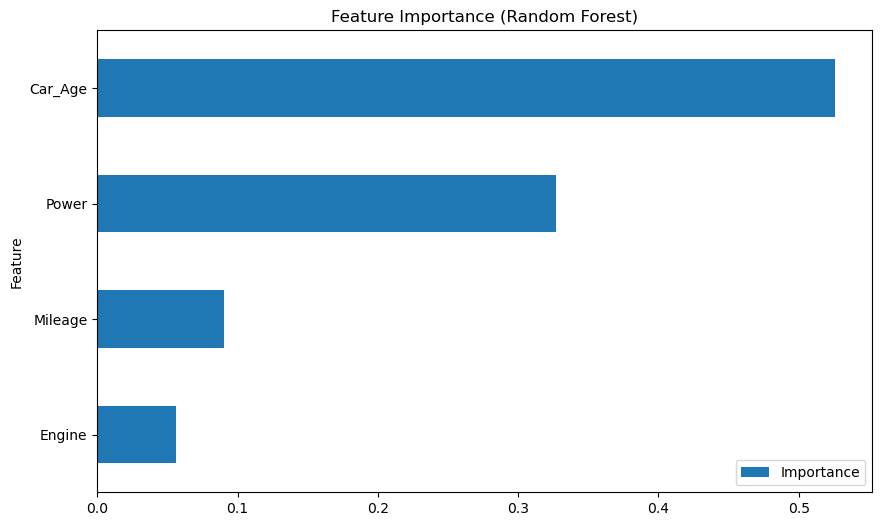

In [118]:
# Visualizing what features drive the price most using feature importance

import matplotlib.pyplot as plt
import pandas as pd

feature_importance = model_rf.feature_importances_
features = X_train.columns  

importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df.sort_values(by='Importance', ascending=True).plot.barh(x='Feature', figsize=(10,6))
plt.title('Feature Importance (Random Forest)')
plt.show()

In [121]:
importance_df.sort_values(by='Importance', ascending=False)

,Feature,Importance
0,Car_Age,0.526133
1,Power,0.326873
3,Mileage,0.090538
2,Engine,0.056456


We can see that for budget cars, car age(0.58) is the most important factor followed by Power(0.32). Mileage(0.09) and engine(0.05) are not so significant factors that explain the price variation. 